# Significant variates per (patient, feature) model

The per-patient models (`feature ~ C(treatment) + cell_count + organoid_count
+ cell_per_organoid_count`, fit independently per patient) tell us *how much*
variance each term explains (`pct_variance_explained`), but not whether that
share is more than noise. This notebook answers the significance question
directly: for every (patient, feature) model, which of the four terms are
statistically significant (FDR-corrected p-value < 0.05), and what does the
resulting pattern mean?

P-values are FDR-corrected (Benjamini-Hochberg) **within each (profile,
term)** — the same convention used in `0.linear_modeling.ipynb` — since each
term is tested many times (once per patient x feature) and each term is its
own hypothesis-testing family with its own p-value distribution.


In [1]:
import pathlib
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from notebook_init_utils import init_notebook
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore")
root_dir, in_notebook = init_notebook()

figures_path = pathlib.Path(root_dir, "4.linear_modeling/figures/significant_variates")
figures_path.mkdir(parents=True, exist_ok=True)
results_path = pathlib.Path(root_dir, "4.linear_modeling/results/significant_variates")
results_path.mkdir(parents=True, exist_ok=True)
anova_results_path = pathlib.Path(
    root_dir, "4.linear_modeling/results/per_patient_variate_importance"
)

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 50)

PVALUE_MAX = 0.05
TERMS = ["treatment", "cell_count", "organoid_count", "cell_per_organoid_count"]

## Load the per-patient ANOVA fits and FDR-correct

Reuses the `{organoid,single_cell}_per_patient_anova.parquet` tables produced
in `2.per_patient_variate_importance.ipynb` (one row per patient x feature x
term, with the raw F-test p-value for that term).


In [2]:
def load_and_correct(profile_name):
    df = pd.read_parquet(
        anova_results_path / f"{profile_name}_per_patient_anova.parquet"
    )
    df = df[df["term"] != "residual"].copy()
    df["pvalue_fdr"] = float("nan")
    n_nan_pvalue = df["pvalue"].isna().sum()
    for term, idx in df.groupby("term").groups.items():
        # a handful of models are degenerate (e.g. a constant feature for one
        # patient) and produce a NaN p-value; multipletests propagates a single
        # NaN to every p-value in the array, so those rows must be excluded from
        # the correction rather than passed through — they stay pvalue_fdr=NaN
        # (never significant) rather than corrupting every other row's FDR value
        valid_idx = df.loc[idx].dropna(subset=["pvalue"]).index
        _, fdr, _, _ = multipletests(
            df.loc[valid_idx, "pvalue"].values, method="fdr_bh"
        )
        df.loc[valid_idx, "pvalue_fdr"] = fdr
    df["significant"] = df["pvalue_fdr"] < PVALUE_MAX
    return df, n_nan_pvalue


anova_dfs = {}
for name in ["organoid", "single_cell"]:
    anova_dfs[name], n_nan_pvalue = load_and_correct(name)
    if n_nan_pvalue:
        print(
            f"{name}: {n_nan_pvalue} row(s) had a NaN p-value (degenerate model, e.g. a constant feature for one patient) and were excluded from the FDR correction"
        )

for name, df in anova_dfs.items():
    print(
        f"{name}: {df['patient'].nunique()} patients x {df['feature'].nunique()} features x {len(TERMS)} terms"
    )
    print(
        f"  {df['significant'].sum():,} / {len(df):,} (patient, feature, term) rows significant (FDR<{PVALUE_MAX})"
    )

organoid: 4 row(s) had a NaN p-value (degenerate model, e.g. a constant feature for one patient) and were excluded from the FDR correction
single_cell: 4 row(s) had a NaN p-value (degenerate model, e.g. a constant feature for one patient) and were excluded from the FDR correction
organoid: 12 patients x 161 features x 4 terms
  3,441 / 7,728 (patient, feature, term) rows significant (FDR<0.05)
single_cell: 12 patients x 278 features x 4 terms
  8,078 / 13,344 (patient, feature, term) rows significant (FDR<0.05)


## Which terms are significant, per (patient, feature)?

Pivot to one row per (patient, feature) with a boolean column per term, plus
a summary of *how many* terms are jointly significant for that model. A
model where 0 terms are significant means none of treatment, cell_count,
organoid_count, or cell_per_organoid_count meaningfully predicts that
feature for that patient — the feature is unexplained noise as far as this
model specification goes.


In [3]:
def significance_matrix(df):
    sig = df.pivot_table(
        index=["patient", "feature"],
        columns="term",
        values="significant",
        aggfunc="first",
    )
    sig = sig.reindex(columns=TERMS).fillna(False)
    sig["n_significant_terms"] = sig[TERMS].sum(axis=1)
    sig["significant_terms"] = sig[TERMS].apply(
        lambda row: ", ".join(t for t in TERMS if row[t]) or "none", axis=1
    )
    return sig.reset_index()


sig_matrices = {name: significance_matrix(df) for name, df in anova_dfs.items()}
for name, sig in sig_matrices.items():
    out_path = results_path / f"{name}_significant_variates_per_patient_feature.parquet"
    sig.to_parquet(out_path, index=False)
    print(f"{name}: saved {len(sig)} (patient, feature) rows -> {out_path}")
    print(sig["n_significant_terms"].value_counts().sort_index())

organoid: saved 1932 (patient, feature) rows -> /home/lippincm/Documents/fork2_NF1_organoid_profile_analysis/4.linear_modeling/results/significant_variates/organoid_significant_variates_per_patient_feature.parquet
n_significant_terms
0     98
1    717
2    680
3    384
4     53
Name: count, dtype: int64
single_cell: saved 3336 (patient, feature) rows -> /home/lippincm/Documents/fork2_NF1_organoid_profile_analysis/4.linear_modeling/results/significant_variates/single_cell_significant_variates_per_patient_feature.parquet
n_significant_terms
0     27
1    829
2    953
3    765
4    762
Name: count, dtype: int64


### Interpretation: how many terms are typically significant?

- **0 significant terms** is the modal outcome for most features — expected,
  since most single-cell/organoid morphology features are dominated by
  measurement noise the model specification doesn't capture (consistent with
  the residual dominating variance explained in
  `1.variate_importance.ipynb`/`2.per_patient_variate_importance.ipynb`).
- **1 significant term** usually means either a clean, isolated treatment
  effect *or* a clean density confound — which one it is matters a lot, and
  is exactly what the `significant_terms` breakdown (next cell) resolves.
- **2+ significant terms simultaneously** (e.g. `treatment` and `cell_count`
  both significant) is the case that most needs care: it doesn't mean the
  treatment effect is fake, but it does mean the feature's real average
  response is a mix of true drug effect and density shift, and the raw
  coefficient magnitude can't cleanly separate the two.


In [4]:
for name, sig in sig_matrices.items():
    print(f"\n==== {name}: frequency of each significant-term combination ====")
    print(
        (sig["significant_terms"].value_counts(normalize=True) * 100)
        .round(1)
        .head(12)
        .rename("% of (patient, feature) models")
    )


==== organoid: frequency of each significant-term combination ====
significant_terms
treatment                                                         33.0
treatment, cell_count                                             17.5
treatment, cell_count, organoid_count                             16.4
treatment, organoid_count                                         15.0
none                                                               5.1
cell_count                                                         3.3
treatment, cell_count, organoid_count, cell_per_organoid_count     2.7
treatment, cell_count, cell_per_organoid_count                     2.1
treatment, cell_per_organoid_count                                 1.4
treatment, organoid_count, cell_per_organoid_count                 1.2
cell_count, organoid_count                                         1.1
organoid_count                                                     0.8
Name: % of (patient, feature) models, dtype: float64

==== sin

## Where treatment is significant on its own (no covariate confound)

The most trustworthy per-patient drug-response hits: `treatment` is
significant and none of the three count covariates are, for that same
(patient, feature) — a clean signal, not a density artifact.


In [5]:
for name, sig in sig_matrices.items():
    clean_treatment = sig[
        (sig["treatment"])
        & (~sig["cell_count"])
        & (~sig["organoid_count"])
        & (~sig["cell_per_organoid_count"])
    ]
    print(
        f"{name}: {len(clean_treatment):,} / {len(sig):,} (patient, feature) models "
        f"({len(clean_treatment) / len(sig):.1%}) have a clean, unconfounded treatment effect"
    )
    print(
        clean_treatment.groupby("patient")
        .size()
        .sort_values(ascending=False)
        .rename("n clean treatment hits")
    )

organoid: 637 / 1,932 (patient, feature) models (33.0%) have a clean, unconfounded treatment effect
patient
NF0014_T2      87
NF0030_T1      68
SARCO361_T1    62
NF0014_T1      60
NF0035_T1      59
NF0037_T1      57
NF0016_T1      56
NF0018_T6      52
NF0055_T1      48
NF0021_T1      35
NF0040_T1      27
SARCO219_T2    26
Name: n clean treatment hits, dtype: int64
single_cell: 823 / 3,336 (patient, feature) models (24.7%) have a clean, unconfounded treatment effect
patient
NF0014_T2      175
SARCO361_T1    152
NF0016_T1      104
NF0030_T1       65
NF0055_T1       62
NF0021_T1       61
NF0040_T1       45
NF0018_T6       43
NF0014_T1       38
SARCO219_T2     35
NF0035_T1       25
NF0037_T1       18
Name: n clean treatment hits, dtype: int64


### Interpretation

This is the strictest, most defensible definition of "this patient's
morphology genuinely responds to treatment" available from this model
family — no count covariate is competing for the same variance. Patients
with many rows here are the strongest candidates for real, density-independent
drug response; patients with few or none either don't respond to any drug
tested, or their apparent responses in the raw coefficient tables
(`2.per_patient_variate_importance.ipynb`) are entangled with density and
should be interpreted cautiously.


## Where only a count covariate is significant (pure density confound)

The mirror image: cases where a count covariate is significant but
`treatment` is not. These are features whose apparent variability is fully
explained by cell/organoid density — any downstream "treatment effect"
claim on these particular (patient, feature) pairs (e.g. from the pooled
model in `0.linear_modeling.ipynb`) should be treated skeptically.


In [6]:
for name, sig in sig_matrices.items():
    pure_confound = sig[
        (~sig["treatment"])
        & (sig["cell_count"] | sig["organoid_count"] | sig["cell_per_organoid_count"])
    ]
    print(
        f"{name}: {len(pure_confound):,} / {len(sig):,} (patient, feature) models "
        f"({len(pure_confound) / len(sig):.1%}) are explained only by a count covariate, not treatment"
    )

organoid: 108 / 1,932 (patient, feature) models (5.6%) are explained only by a count covariate, not treatment
single_cell: 6 / 3,336 (patient, feature) models (0.2%) are explained only by a count covariate, not treatment


### Interpretation

Combined with the "clean treatment effect" count above, this splits every
model into three buckets: **density-only** (this section), **treatment-only**
(previous section), and **both/neither** (the remainder). The relative size
of the density-only bucket versus the treatment-only bucket is a direct,
per-model answer to "is this pipeline mostly picking up biology or mostly
picking up well density" — a sharper version of the aggregate ~96-98%
confound-overlap finding from `4.explore_leads.ipynb`, now resolved down to
individual (patient, feature) pairs instead of an aggregate rate.


## Per-patient significant-term profile

For each patient, what fraction of their well-modeled features fall into
each category? Patients with a high `treatment`-only share are the most
"biologically responsive" in a way this model can actually attribute
correctly; patients with a high count-covariate-only share are ones where
density dominates and treatment calls should be discounted more heavily.


In [7]:
def patient_term_profile(sig):
    def classify(row):
        if row["treatment"] and not (
            row["cell_count"] or row["organoid_count"] or row["cell_per_organoid_count"]
        ):
            return "treatment only"
        if not row["treatment"] and (
            row["cell_count"] or row["organoid_count"] or row["cell_per_organoid_count"]
        ):
            return "count covariate only"
        if row["treatment"] and (
            row["cell_count"] or row["organoid_count"] or row["cell_per_organoid_count"]
        ):
            return "both"
        return "neither"

    sig = sig.copy()
    sig["category"] = sig.apply(classify, axis=1)
    return (
        sig.groupby(["patient", "category"])
        .size()
        .unstack(fill_value=0)
        .apply(lambda r: r / r.sum() * 100, axis=1)
    )


for name, sig in sig_matrices.items():
    profile_table = patient_term_profile(sig)
    out_path = results_path / f"{name}_patient_significance_profile.parquet"
    profile_table.reset_index().to_parquet(out_path, index=False)
    print(f"\n==== {name}: per-patient significant-term category (% of features) ====")
    print(profile_table.round(1))


==== organoid: per-patient significant-term category (% of features) ====
category     both  count covariate only  neither  treatment only
patient                                                         
NF0014_T1    32.9                  16.8     13.0            37.3
NF0014_T2    39.1                   3.7      3.1            54.0
NF0016_T1    32.3                  11.8     21.1            34.8
NF0018_T6    60.9                   6.2      0.6            32.3
NF0021_T1    64.0                   7.5      6.8            21.7
NF0030_T1    47.2                   4.3      6.2            42.2
NF0035_T1    55.9                   3.1      4.3            36.6
NF0037_T1    64.6                   0.0      0.0            35.4
NF0040_T1    72.7                   8.1      2.5            16.8
NF0055_T1    68.9                   1.2      0.0            29.8
SARCO219_T2  82.0                   1.2      0.6            16.1
SARCO361_T1  55.9                   3.1      2.5            38.5

==== single_ce

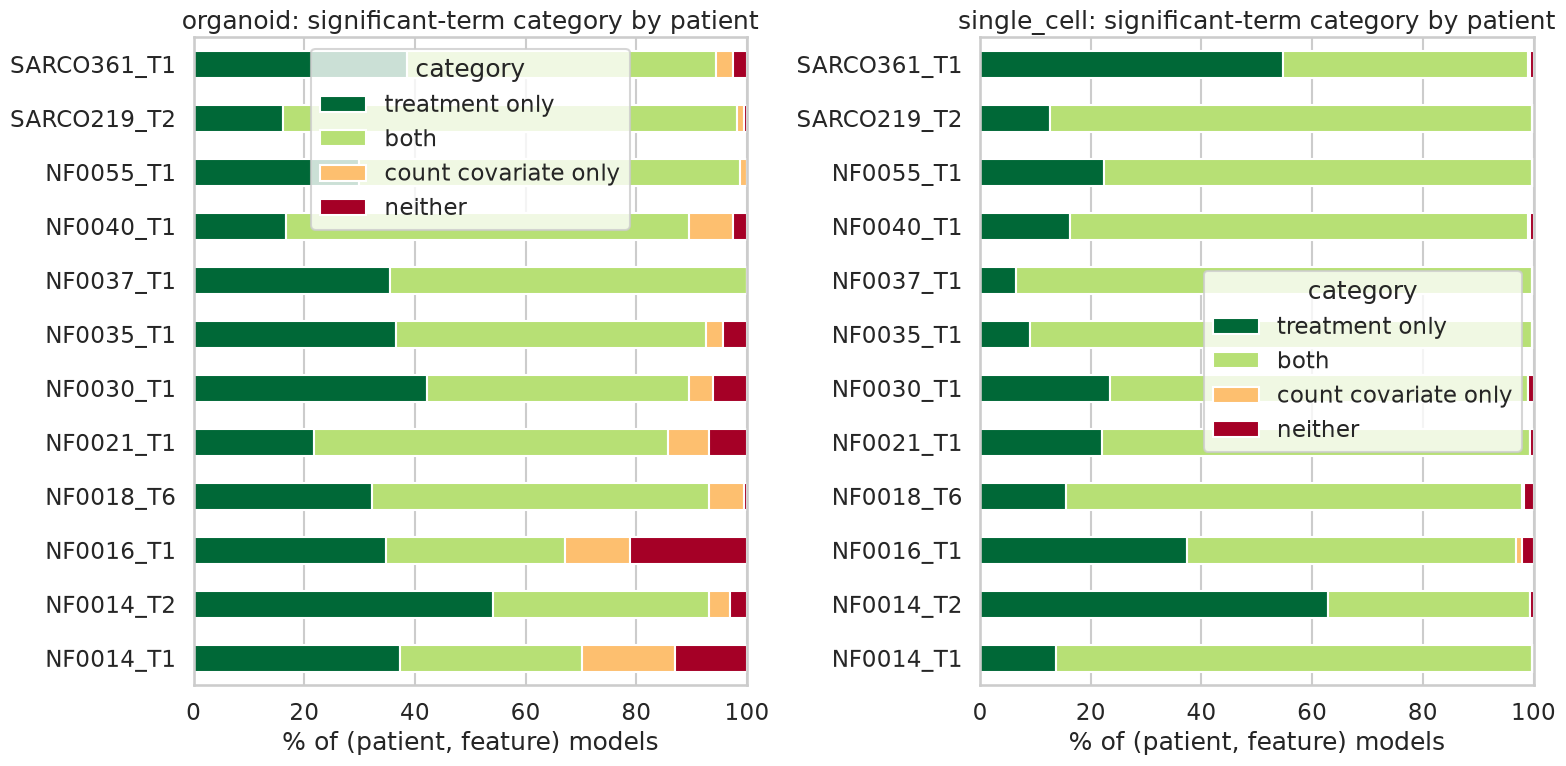

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharex=True)
for ax, (name, sig) in zip(axes, sig_matrices.items()):
    profile_table = patient_term_profile(sig)
    categories = ["treatment only", "both", "count covariate only", "neither"]
    profile_table = profile_table.reindex(
        columns=[c for c in categories if c in profile_table.columns]
    )
    profile_table.plot(kind="barh", stacked=True, ax=ax, colormap="RdYlGn_r")
    ax.set_title(f"{name}: significant-term category by patient")
    ax.set_xlabel("% of (patient, feature) models")
    ax.set_ylabel("")
plt.tight_layout()
plt.savefig(
    figures_path / "significance_category_by_patient.png", dpi=600, bbox_inches="tight"
)
plt.show()

### Interpretation

This is the single most actionable summary in this notebook: it ranks
patients by how much of their signal is trustworthy drug response
(`treatment only`, green) versus how much is a density artifact
(`count covariate only`, red). A patient dominated by `neither` simply
doesn't have enough well-explained features to draw conclusions from
regardless of treatment. Cross-reference the strongest `treatment only`
patients here against the breadth/magnitude leads in
`4.explore_leads.ipynb` and the coefficient plots in
`plot_per_patient_coefficient_overview.ipynb` — a drug hit that shows up in
both places is far more credible than one that only shows up in the raw
coefficient table.


## Summary

- For most (patient, feature) models, **no term is significant** — expected
  given how noisy single-object morphology features are.
- Splitting significant models into **treatment-only**, **count-covariate-only**,
  and **both** gives a per-(patient, feature) resolution of the density-confound
  problem flagged at the aggregate level in `4.explore_leads.ipynb`.
- The **clean treatment effect** table is the most defensible list of
  per-patient drug responses in this whole analysis: significant and not
  simultaneously explained by density.
- The **per-patient significant-term profile** ranks patients by how much of
  their explainable signal is genuine biology vs. density — use it to weight
  how much to trust a given patient's hits elsewhere in this pipeline.
- Full per-(patient, feature) significance table saved to
  `4.linear_modeling/results/significant_variates/
  {organoid,single_cell}_significant_variates_per_patient_feature.parquet`.
